In [6]:
!pip install langchain langgraph openai typing_extensions


  Using cached pydantic-2.12.5-py3-none-any.whl.metadata (90 kB)
  Using cached pydantic_core-2.41.5-cp312-cp312-win_amd64.whl.metadata (7.4 kB)
Using cached pydantic-2.12.5-py3-none-any.whl (463 kB)
Using cached pydantic_core-2.41.5-cp312-cp312-win_amd64.whl (2.0 MB)

  Attempting uninstall: pydantic-core

    Found existing installation: pydantic_core 2.14.1

    Uninstalling pydantic_core-2.14.1:

      Successfully uninstalled pydantic_core-2.14.1

   ---------------------------------------- 0/2 [pydantic-core]
  Attempting uninstall: pydantic
   ---------------------------------------- 0/2 [pydantic-core]
    Found existing installation: pydantic 2.5.0
   ---------------------------------------- 0/2 [pydantic-core]
   -------------------- ------------------- 1/2 [pydantic]
    Uninstalling pydantic-2.5.0:
   -------------------- ------------------- 1/2 [pydantic]
      Successfully uninstalled pydantic-2.5.0
   -------------------- ------------------- 1/2 [pydantic]
   -----------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydata-profiling 4.16.1 requires statsmodels<1,>=0.13.2, which is not installed.
google-generativeai 0.8.5 requires google-ai-generativelanguage==0.6.15, but you have google-ai-generativelanguage 0.9.0 which is incompatible.
gradio 5.49.1 requires fastapi<1.0,>=0.115.2, but you have fastapi 0.104.1 which is incompatible.
gradio 5.49.1 requires huggingface-hub<2.0,>=0.33.5, but you have huggingface-hub 0.24.7 which is incompatible.
gradio 5.49.1 requires pydantic<2.12,>=2.0, but you have pydantic 2.12.5 which is incompatible.
gradio 5.49.1 requires python-multipart>=0.0.18, but you have python-multipart 0.0.6 which is incompatible.
gradio 5.49.1 requires starlette<1.0,>=0.40.0, but you have starlette 0.27.0 which is incompatible.
langchain-community 0.4.1 requires requests<3.0.0,>=2.32.5, but you have requests 2.31.

In [8]:
import langgraph


In [38]:
from langgraph.graph import StateGraph, START,END
from typing import TypedDict

In [82]:
# define state
class bmi(TypedDict):
    height_kg: float
    weight_kg:float
    bmi:float
    category : str


In [ ]:
# calll the function

In [42]:
def calculator(state:bmi) -> bmi:
    height = state["height_kg"]
    
    weight = state["weight_kg"]
    
    bmi = weight/(height**2)
    
    state['bmi'] = round(bmi,2)
    
    return state

In [102]:
# lable de rhe hai sahi na 
def label_bmi(state:bmi) ->bmi:
    bmi = state['bmi']
    if bmi <0.1:
        state["category"] ="overweight"
    elif bmi<1 and bmi>1000:
         state["category"] = "underweight"
    elif bmi<20 or bmi >40:
        state["category"] = "Usman"
    else:
        state["category"] = "oberve"
    return state

In [104]:
# define graph
graph = StateGraph(bmi)


# add nodes to your graph
graph.add_node("calculator", calculator)
graph.add_node("label_bmi", label_bmi)


# add edges to the graph
graph.add_edge(START, "calculator")
graph.add_edge("calculator", "label_bmi")
graph.add_edge("label_bmi", END)


# compile the graph
workflow = graph.compile()


In [106]:
initial_state  = {'height_kg':10,"weight_kg":20}
output_state = workflow.invoke(initial_state)
print(output_state)

{'height_kg': 10, 'weight_kg': 20, 'bmi': 0.2, 'category': 'Usman'}


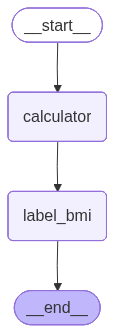

In [108]:
# show graph 
graph.compile()